# Testing DRT fitting

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from redoxed.data_loading.data_loaders import LoaderFactory, BiologicLoader, CSVLoader
from redoxed.plots import NyquistPlot, DRTPlot, ResidualsPlot, PolarisationPlot
from redoxed.impedance import EISData, DRTData, ResidualsData
from redoxed.impedance.drt_analysis import HN_Z, HN_DRT, SG_DRT, fit_DRT_peaks, find_DRT_peaks, Z_from_DRT
from redoxed.dc import PolarisationData

from redoxed import config
config.set_latex_mode(False) # warning, slows plotting if True. Used to achieve consistent serif fonts by rendering latex. 

from pyimpspec import (
    ComplexImpedances,    # Alias for a NumPy array of complex128 values
    Frequencies,          # Alias for a NumPy array of float64 values
    Circuit,
    DataSet,
    FitResult,
    Element,              # The base class for all circuit elements
    ElementDefinition,    # A class that contains information regarding a new circuit element
    ParameterDefinition,  # A class that contains information regarding a circuit element's parameter
    register_element,     # A function that processes the new element class
    parse_cdc,
    fit_circuit,
)

from pyimpspec import perform_zhit, ZHITResult

import pyDRTtools

%matplotlib inline

# if think is slowing down, disable autoreload by restarting kernel without it.
%load_ext autoreload
%autoreload 2 

# Get tab10 colors and names (colorblind friendly)
cmap = plt.get_cmap('tab10')
tab10_names = [
    "blue", "orange", "green", "red", "purple",
    "brown", "pink", "gray", "olive", "cyan"]
tab10_colors = cmap.colors
# Create a name-to-color dictionary
colour_dict = dict(zip(tab10_names, tab10_colors))
colour_dict["black"] = (0, 0, 0) # add black color

Initializing pyDRTtools from c:\users\es758\documents\github\pydrttools
['c:\\Users\\es758\\anaconda3\\envs\\RFB_es758\\python313.zip', 'c:\\Users\\es758\\anaconda3\\envs\\RFB_es758\\DLLs', 'c:\\Users\\es758\\anaconda3\\envs\\RFB_es758\\Lib', 'c:\\Users\\es758\\anaconda3\\envs\\RFB_es758', '', 'c:\\Users\\es758\\anaconda3\\envs\\RFB_es758\\Lib\\site-packages', 'C:\\Users\\es758\\Documents\\GitHub\\redoxED\\src', 'c:\\users\\es758\\documents\\github\\pydrttools', 'c:\\users\\es758\\documents\\github\\nanodrt', 'C:\\Users\\es758\\Documents\\GitHub\\phd_tools', 'c:\\Users\\es758\\anaconda3\\envs\\RFB_es758\\Lib\\site-packages\\win32', 'c:\\Users\\es758\\anaconda3\\envs\\RFB_es758\\Lib\\site-packages\\win32\\lib', 'c:\\Users\\es758\\anaconda3\\envs\\RFB_es758\\Lib\\site-packages\\Pythonwin', 'c:\\Users\\es758\\anaconda3\\envs\\RFB_es758\\Lib\\site-packages\\yadg']
Imported basics
Imported BHT
Imported cli
Imported GUI
Imported HMC
Imported layout
Imported nearest_PD
Imported parameter_sele

## Inductance fit

[8914.929   7943.999   7082.2314  6307.734   5621.0557  5011.604
 4466.429   3981.2744  3546.5955  3161.0117  2817.2954  2510.8032
 2237.8518  1995.6388  1778.2926  1585.5074  1411.8373  1258.7913
 1121.7952  1000.3202   891.4262   794.23785  707.50934  631.00964
  562.33936  501.44418  446.85892  398.08914  354.65955  316.3159
  281.89435  251.04433  223.92519  199.553    177.78128  158.4284
  141.31136  125.84567  112.18995  100.03201]


,Element,Parameter,Value,Std. err. (%),Unit,Fixed
0,R_0,R,1.611137e-02,NaN,ohm,No
1,La_1,L,9.146228e-08,NaN,H*s^(n-1),No
2,La_1,n,9.464568e-01,NaN,,No


,Label,Value
0,Log pseudo chi-squared,-3.242606
1,Log chi-squared,-15.050738
2,Log chi-squared (reduced),-16.937228
3,Akaike info. criterion,-3117.01046
4,Bayesian info. criterion,-3109.86438
5,Degrees of freedom,77
6,Number of data points,80
7,Number of function evaluations,955
8,Method,powell
9,Weight,unity


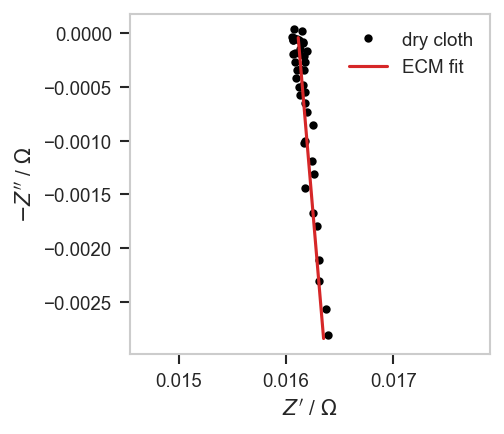

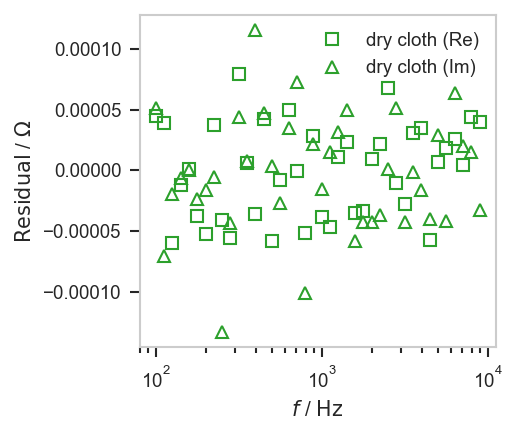

In [89]:
# initialise plot dictionaries
eis_plot_dict = {}
drt_plot_dict = {}
residuals_plot_dict = {}

#########################
##### Data loading ######
#########################

fpath = r"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.09.26 FB1_dry_1186HCB\2_1186HCB_4Nm_02_GEIS_C04.mpr"
ECData_object = BiologicLoader().load_data(fpath=fpath)
# print(ECData_object.df["cycle number"].to_numpy()[-1])
ECData_object.df = ECData_object.filter_by_col("cycle number", lambda value: value == 1)
EISData_object = ECData_object.to_EISData()
EISData_object.crop_frequency(0.01, 1e4)
#EISData_object.crop_frequency(1e3, 1e4)
EISData_object.label = "dry cloth"
eis_plot_dict[EISData_object.label] = {
        "data": EISData_object,
        "plot_kwargs": {"color": colour_dict["black"], "linestyle": "", "marker": ".", "label": EISData_object.label},
        "plot": True
    }

#########################
#### Circuit fitting ####
#########################
print(EISData_object.f)
data: DataSet = DataSet(frequencies = EISData_object.f, impedances= EISData_object.Z, mask = None, path = "", label = EISData_object.label, uuid = "")
# circuit: Circuit = parse_cdc("[LR(Q[RWs])]")
circuit: Circuit = parse_cdc("[RLa]")
fit: FitResult = fit_circuit(
  circuit, 
  data,
  # method = "least_squares",
  method = "auto",
  weight = "auto",
  # weight = "boukamp", # value relative deviatons equally 
  # weight = "unity", # value deviations equally
  # weight = "modulus", # value high Z more
  max_nfev=-1, num_procs=-1, timeout=0, constraint_expressions=None, constraint_variables=None)
freq_fit, real_resid_percent, imag_resid_percent = fit.get_residuals_data() 
real_z, neg_imag_z = fit.get_nyquist_data(num_per_decade=-1) # default is frequency points used for fit, otherwise can set to make more refined.
EISData_circuit = EISData(Z = real_z - 1j * neg_imag_z, f = freq_fit, label = "ECM fit")
eis_plot_dict[EISData_circuit.label] = {
        "data": EISData_circuit,
        "plot_kwargs": {"color": colour_dict["red"], "linestyle": "-", "marker": "", "label": EISData_circuit.label},
        "plot": True
    }
## show results
df: pd.DataFrame = fit.to_parameters_dataframe(running=True) # set true to start from 0
# parameters: str = df.to_markdown(index=False)
parameters = df
df = fit.to_statistics_dataframe()
# statistics: str = df.to_markdown(index=False)
statistics = df
# display(Markdown(parameters))
# display(Markdown(statistics))
display(parameters)
display(statistics)
# ## simulate
# # data: DataSet = simulate_spectrum(fit.circuit, frequencies=np.logspace(3, 0, num=16), label="Randles")
# # fit.circuit.get_elements()[-1].get_values()
# ## show drawing
# drawing: Drawing = circuit.to_drawing(running=True, hide_labels = True)
# ## Useful other arguments
# # hide_labels: bool = False,
# # running: bool = False,
# # custom_labels: Optional[Dict[Element, str]] = None,
# # canvas: Optional[Union[str, "Axes"]] = None,  # noqa: F821
# display(drawing)
# #drawing.save(fname = "simple_circuit.svg", transparent = True, dpi = 72)

#########################
### Circuit Residuals ###
#########################

observed = EISData_object
predicted = EISData_circuit
residuals_plot_dict[EISData_object.label] = {
        "data": ResidualsData().calculate_residuals(observed = observed, predicted = predicted),
        "plot_kwargs": {"color": colour_dict["green"], "linestyle": "", "mfc": "none", "label": EISData_object.label},
        "plot": True
    }

#########################
##### DRT fitting #######
#########################

# DRTData_object = DRTData(gamma=gamma, tau=tau)
# DRTData_object.label = "DRT exact"
# drt_plot_dict[DRTData_object.label] = {
#         "data": DRTData(gamma=gamma, tau=tau),
#         "plot_kwargs": {"color": colour_dict["black"], "linestyle": "-", "marker": "", "label": DRTData_object.label},
#         "plot": True
#     }



#########################
## Create Nyquist Plot ##
#########################
NyquistPlot_object = NyquistPlot(figsize=(3.543, 3), dpi = 150) 
for label, entry in eis_plot_dict.items():
    if entry["plot"]:
        NyquistPlot_object.add_plot(entry["data"], **entry["plot_kwargs"])
NyquistPlot_object.ax.set_aspect("equal", adjustable="datalim")  # if enable, overall fig size will be strictly enforced, but x and y limits will be overwritten. So will padding of labels I think.
# # NyquistPlot_object.ax.set_aspect('equal',adjustable='box') # if enable this, fig size will get overwritten, at least in y. but can set x and y lim
# # Best way is to control size using adjustable = "datalim", and then plot invisible points to ensure points are in view if desired. Less useful for cropping.
# # NyquistPlot_object.ax.grid(True)
# NyquistPlot_object.add_major_ticks(spacing_x = 1, spacing_y = 1)
# # NyquistPlot_object.add_minor_ticks(number_x = 5, number_y = 5)
NyquistPlot_object.ax.legend()
NyquistPlot_object.fig.tight_layout() # try stop cutting off labels
display(NyquistPlot_object.fig)
# NyquistPlot_object.save("Nyquist.svg") # may need to adjust fontsize or use bbox_inches='tight' to stop cutting off labels

# #########################
# #### Create DRT Plot ####
# #########################
# DRTPlot_object = DRTPlot(figsize=(3.543, 3), dpi = 150)
# for label, entry in drt_plot_dict.items():
#     if entry["plot"]:
#         DRTPlot_object.add_plot(entry["data"], **entry["plot_kwargs"])
# DRTPlot_object.add_major_ticks(spacing_y = 1)
# # # DRTPlot_object.add_minor_ticks(number_x = 5, number_y = 5)
# DRTPlot_object.add_fc_axis() # only use after enforcing DRTPlot_object.ax.set_xlim([0, None]) if desired
# DRTPlot_object.fig.tight_layout() # try stop cutting off labels
# display(DRTPlot_object.fig)
# # DRTPlot_object.save("DRT.svg") # may need to adjust fontsize or use bbox_inches='tight' to stop cutting off labels

###########################
## Create Residuals Plot ##
###########################
# ResidualsPlot_object = ResidualsPlot(figsize=(3.543, 3), dpi = 150, mode = 'relative') # gets a bit misleading for small Z
ResidualsPlot_object = ResidualsPlot(figsize=(3.543, 3), dpi = 150, mode = 'absolute')
for label, entry in residuals_plot_dict.items():
    if entry["plot"]:
        ResidualsPlot_object.add_plot(entry["data"], **entry["plot_kwargs"])
ResidualsPlot_object.fig.tight_layout() # try stop cutting off labels
ResidualsPlot_object.ax.legend()
display(ResidualsPlot_object.fig)

## Validation

,Label,Value
0,Log pseudo chi-squared,9.28596
1,Smoothing,modsinc
2,Interpolation,makima
3,Window,boxcar


,Label,Value
0,Log pseudo chi-squared,9.405606
1,Smoothing,modsinc
2,Interpolation,makima
3,Window,boxcar


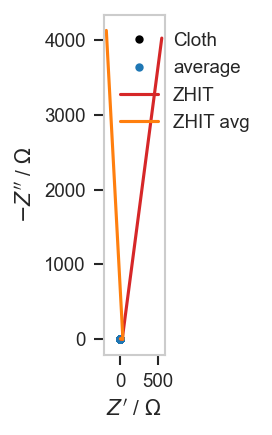

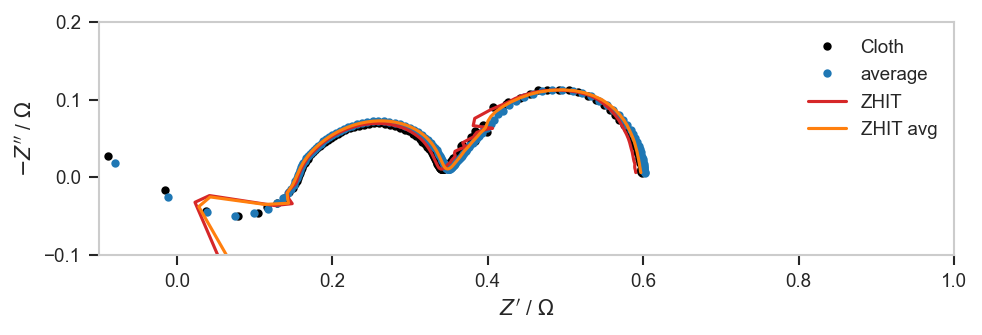

In [91]:
# initialise plot dictionaries
eis_plot_dict = {}
residuals_plot_dict = {}

#########################
##### Data loading ######
#########################
# # felt
label = "Felt"
fpath = r"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.03.06 FB1_FCN_KCl_E620K_GFDBO_B3cutedge\1_50ml_50soc_20mM_FCN_33rpm_air_03_GEIS_C02.mpr"
# # cloth
label = "Cloth"
fpath = r"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.06.15 FB2_FCN_KCl_E620K_1186HCB\17_replelec_C04.mpr"

fpath = fpath
ECData_object = BiologicLoader().load_data(fpath=fpath)
# print(ECData_object.df["cycle number"].to_numpy()[-1])
ECData_object.df = ECData_object.filter_by_col("cycle number", lambda value: value == 2)
EISData_object = ECData_object.to_EISData()
# EISData_object.crop_frequency(0.01, 2e5)
#EISData_object.crop_frequency(1e5, 2e5)
EISData_object.label = label
eis_plot_dict[EISData_object.label] = {
        "data": EISData_object,
        "plot_kwargs": {"color": colour_dict["black"], "linestyle": "", "marker": ".", "label": EISData_object.label},
        "plot": True
    }

fpath = fpath
ECData_object = BiologicLoader().load_data(fpath=fpath)
ECData_object_temp = BiologicLoader().load_data(fpath=fpath)
# print(ECData_object.df["cycle number"].to_numpy()[-1])
# use first cycle
ECData_object_temp.df = ECData_object.filter_by_col("cycle number", lambda value: value == 1)
EISData_object_1 = EISData_object_temp = ECData_object_temp.to_EISData()
N = 0
Z_temp = np.zeros_like(EISData_object_1.Z)
f = EISData_object_1.f
for i in np.unique(ECData_object.df["cycle number"].to_numpy()):
    ECData_object_temp.df = ECData_object.filter_by_col("cycle number", lambda value: value == i)
    try:
        EISData_object_temp = ECData_object_temp.to_EISData()
        Z_temp += EISData_object_temp.Z
        N += 1
    except Exception as e:
        print(f"Error processing cycle {i}: {e}")
        continue
EISData_object_avg = EISData(f = f, Z = Z_temp / N)
# EISData_object.crop_frequency(0.01, 2e5)
# EISData_object.crop_frequency(1e5, 2e5)
EISData_object_avg.label = "average"
eis_plot_dict[EISData_object_avg.label] = {
        "data": EISData_object_avg,
        "plot_kwargs": {"color": colour_dict["blue"], "linestyle": "", "marker": ".", "label": EISData_object_avg.label},
        "plot": True
    }



#########################
##### ZHIT fitting ######
#########################
data: DataSet = DataSet(frequencies = EISData_object.f, impedances= EISData_object.Z, mask = None, path = "", label = EISData_object.label, uuid = "")
# important to set center and width to cover frequency range well.
# default is center = 1.5 and width = 3 (1-1000 Hz)
# I prefer center 2.5 (10-10,000 Hz) as the region minimally affected by artefacts 
zhit: ZHITResult = perform_zhit(data, center = 2.5, width = 3.0) 
EISData_zhit = EISData(zhit.get_impedances(), f = zhit.get_frequencies(), label = "ZHIT")
eis_plot_dict[EISData_zhit.label] = {
        "data": EISData_zhit,
        "plot_kwargs": {"color": colour_dict["red"], "linestyle": "-", "marker": "", "label": EISData_zhit.label},
        "plot": True
    }
## show results
df = zhit.to_statistics_dataframe()
statistics = df
display(statistics)

data: DataSet = DataSet(frequencies = EISData_object_avg.f, impedances= EISData_object_avg.Z, mask = None, path = "", label = EISData_object_avg.label, uuid = "")
# important to set center and width to cover frequency range well.
# default is center = 1.5 and width = 3 (1-1000 Hz)
# I prefer center 2.5 (10-10,000 Hz) as the region minimally affected by artefacts 
zhit: ZHITResult = perform_zhit(data, center = 2.5, width = 3.0) 
EISData_zhit_avg = EISData(zhit.get_impedances(), f = zhit.get_frequencies(), label = "ZHIT avg")
eis_plot_dict[EISData_zhit_avg.label] = {
        "data": EISData_zhit_avg,
        "plot_kwargs": {"color": colour_dict["orange"], "linestyle": "-", "marker": "", "label": EISData_zhit_avg.label},
        "plot": True
    }
## show results
df = zhit.to_statistics_dataframe()
statistics = df
display(statistics)

#########################
#### ZHIT Residuals #####
#########################

observed = EISData_object
predicted = EISData_zhit
residuals_plot_dict[EISData_object.label] = {
        "data": ResidualsData().calculate_residuals(observed = observed, predicted = predicted),
        "plot_kwargs": {"color": colour_dict["red"], "linestyle": "", "mfc": "none", "label": EISData_object.label},
        "plot": True
    }

observed = EISData_object_avg
predicted = EISData_zhit_avg
residuals_plot_dict[EISData_object_avg.label] = {
        "data": ResidualsData().calculate_residuals(observed = observed, predicted = predicted),
        "plot_kwargs": {"color": colour_dict["orange"], "linestyle": "", "mfc": "none", "label": EISData_object_avg.label},
        "plot": True
    }


#########################
## Create Nyquist Plot ##
#########################
NyquistPlot_object = NyquistPlot(figsize=(6, 3), dpi = 150) 
for label, entry in eis_plot_dict.items():
    if entry["plot"]:
        NyquistPlot_object.add_plot(entry["data"], **entry["plot_kwargs"])
NyquistPlot_object.ax.set_aspect("equal", adjustable="datalim")  # if enable, overall fig size will be strictly enforced, but x and y limits will be overwritten. So will padding of labels I think.
NyquistPlot_object.ax.set_aspect('equal',adjustable='box') # if enable this, fig size will get overwritten, at least in y. but can set x and y lim
# # Best way is to control size using adjustable = "datalim", and then plot invisible points to ensure points are in view if desired. Less useful for cropping.
# # NyquistPlot_object.ax.grid(True)
# NyquistPlot_object.add_major_ticks(spacing_x = 1, spacing_y = 1)
# # NyquistPlot_object.add_minor_ticks(number_x = 5, number_y = 5)
NyquistPlot_object.ax.legend()
NyquistPlot_object.fig.tight_layout() # try stop cutting off labels
display(NyquistPlot_object.fig)
NyquistPlot_object.ax.set_ylim(-0.1, 0.2)
NyquistPlot_object.ax.set_xlim(-0.1, 1)
display(NyquistPlot_object.fig)
# NyquistPlot_object.save("Nyquist.svg") # may need to adjust fontsize or use bbox_inches='tight' to stop cutting off labels

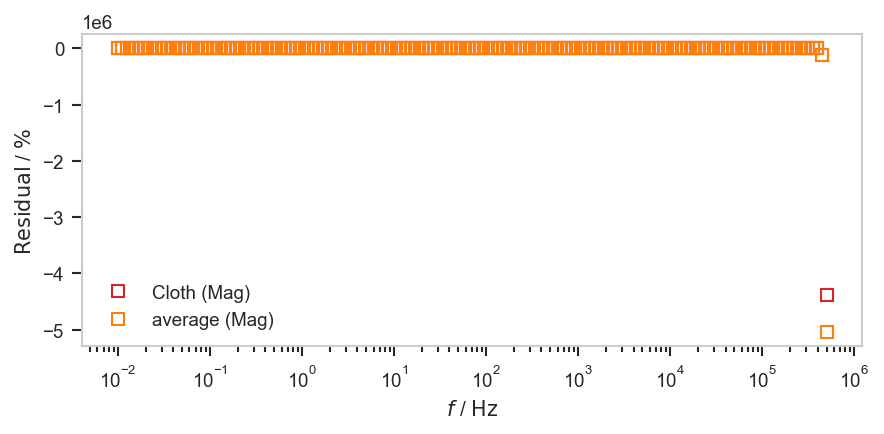

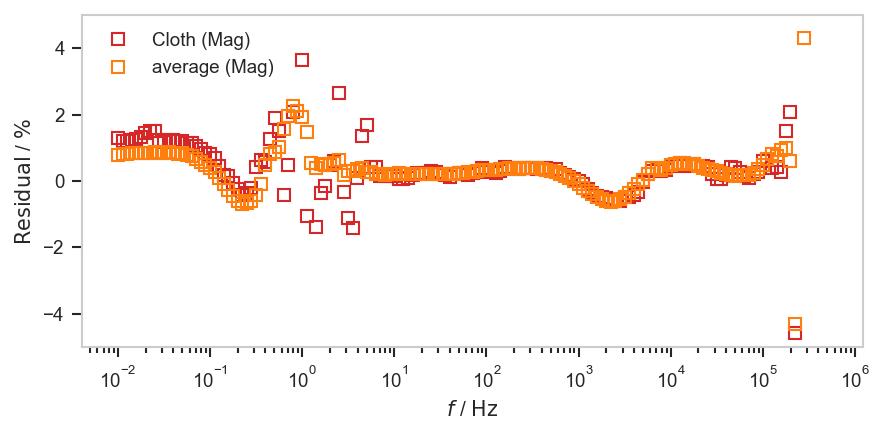

In [53]:


###########################
## Create Residuals Plot ##
###########################
ResidualsPlot_object = ResidualsPlot(figsize=(6, 3), dpi = 150, mode = 'relative', Z_rep='polar') # gets a bit misleading for small Z
#ResidualsPlot_object = ResidualsPlot(figsize=(3.543, 3), dpi = 150, mode = 'relative',  Z_rep='cartesian')
for label, entry in residuals_plot_dict.items():
    if entry["plot"]:
        if ResidualsPlot_object.Z_rep == 'polar':
            # disable phase plotting
            entry["data"].residuals_phase = None
            entry["data"].residuals_phase_rel = None
            ResidualsPlot_object.ax_phase.set_visible(False)
        # plot
        ResidualsPlot_object.add_plot(entry["data"], **entry["plot_kwargs"])
ResidualsPlot_object.fig.tight_layout() # try stop cutting off labels
ResidualsPlot_object.ax.legend()
display(ResidualsPlot_object.fig)
ResidualsPlot_object.ax.set_ylim([-5, 5])
# ResidualsPlot_object.ax_phase.set_ylim([-5, 5])
ResidualsPlot_object.fig.tight_layout() # try stop cutting off labels
ResidualsPlot_object.ax.legend()
display(ResidualsPlot_object.fig)


## DRT fit

ed's tau adjustment made


c:\users\es758\documents\github\pydrttools\pyDRTtools\basics.py:59: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  out_val = integrate.quad(integrand_g_i, -50, 50, epsabs=1E-9, epsrel=1E-9)
c:\users\es758\documents\github\pydrttools\pyDRTtools\basics.py:92: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  out_val = integrate.quad(integrand_g_ii, -50, 50, epsabs=1E-9, epsrel=1E-9)


The value of the regularization parameter is 1e-09
     pcost       dcost       gap    pres   dres
 0: -2.2404e+01 -2.4620e+01  2e+02  1e+01  7e-05
 1: -2.1794e+01 -2.5435e+01  2e+01  2e+00  9e-06
 2: -2.2065e+01 -2.4314e+01  2e+00  2e-02  9e-08
 3: -2.2240e+01 -2.3124e+01  9e-01  5e-03  3e-08
 4: -2.2323e+01 -2.2924e+01  6e-01  1e-03  6e-09
 5: -2.2384e+01 -2.2486e+01  1e-01  1e-04  8e-10
 6: -2.2405e+01 -2.2434e+01  3e-02  1e-06  6e-12
 7: -2.2409e+01 -2.2413e+01  4e-03  1e-07  6e-13
 8: -2.2410e+01 -2.2411e+01  1e-03  7e-17  1e-16
 9: -2.2410e+01 -2.2410e+01  2e-04  3e-17  8e-18
10: -2.2410e+01 -2.2410e+01  1e-04  1e-16  5e-16
11: -2.2410e+01 -2.2410e+01  2e-05  4e-17  7e-16
Optimal solution found.


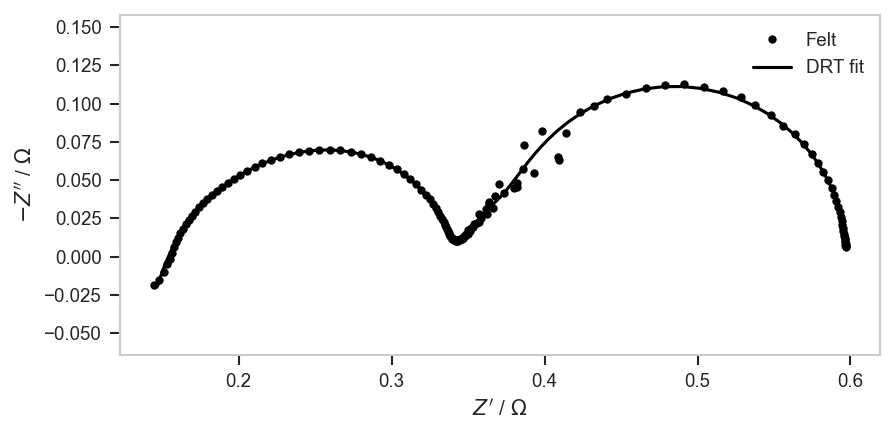

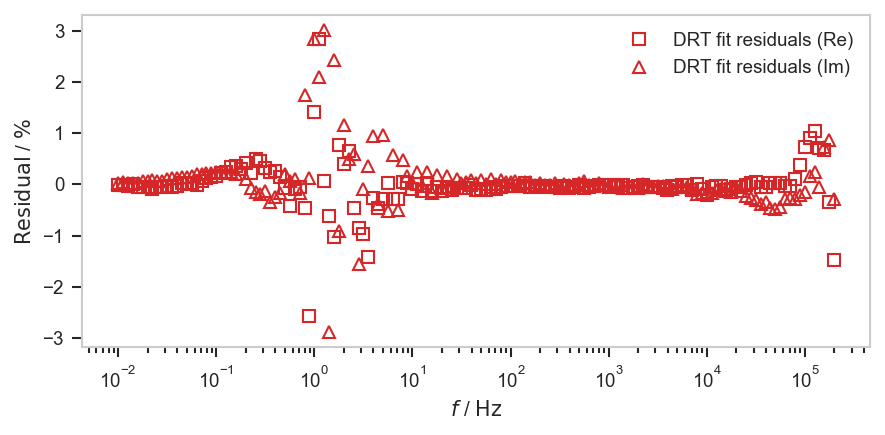

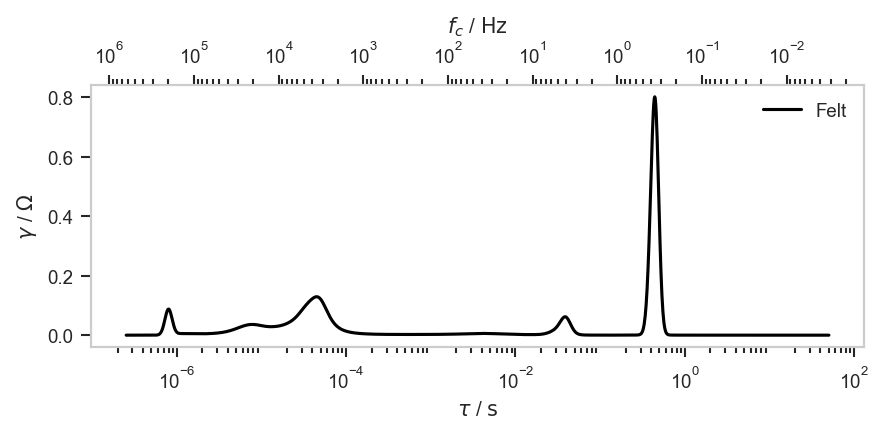

DRT R0: 0.13438104653357807
Inductance L: 3.1654836308523885e-08


In [94]:
# initialise plot dictionaries
eis_plot_dict = {}
drt_plot_dict = {}
residuals_plot_dict = {}

#########################
##### Data loading ######
#########################

fpath = fpath
ECData_object = BiologicLoader().load_data(fpath=fpath)
# print(ECData_object.df["cycle number"].to_numpy()[-1])
ECData_object.df = ECData_object.filter_by_col("cycle number", lambda value: value == 6)
EISData_object = ECData_object.to_EISData()
EISData_object.crop_frequency(0.01, 2e5)
# EISData_object.crop_frequency(0.01, 1e4)
EISData_object.label = "Felt"
eis_plot_dict[EISData_object.label] = {
        "data": EISData_object,
        "plot_kwargs": {"color": colour_dict["black"], "linestyle": "", "marker": ".", "label": EISData_object.label},
        "plot": True
    }


#########################
###### DRT fitting ######
#########################

lambda_0 = 1e-9 # initial guess for regularization parameter
# lambda_0 = 1e-4

pyDRTtools_EIS_object = pyDRTtools.runs.EIS_object(
        EISData_object.f, EISData_object.Z_re, EISData_object.Z_im, ed_adjust = True
    )
# this includes tau definition of
# # self.tau = 1/freq # we assume that the collocation points equal to 1/freq as default
# # self.tau_fine  = np.logspace(log10(self.tau.min())-0.5,log10(self.tau.max())+0.5,10*freq.shape[0]

lambda_0 = lambda_0 # initial guess

induct_used = 1 # 1 means do keep inductive and fit inductance.
der_used = '1st order'
cv_type = 'custom' # fix lambda
reg_param = lambda_0
shape_control = "FWHM Coefficient" # otherwise coeff is treated as their definition of shape factor mu
coeff = 0.5 # FWHM twice log spacing means coef 0.5. Is done so there is good overlap.
# coeff = 0.05
rbf_type = "Gaussian" # Gaussian is the default, Cauchy bad.
# rbf_type = "PWL"
data_used = "Combined Re-Im Data"
# ridge regression DRT
fitted_entry = pyDRTtools.runs.simple_run(
    entry=pyDRTtools_EIS_object,
    rbf_type=rbf_type,
    data_used=data_used,
    induct_used=induct_used,
    der_used=der_used,
    cv_type=cv_type,
    reg_param=reg_param,
    shape_control=shape_control,
    coeff=coeff,
)
### If want to mute the console, can use something like this with simple_run nested in
# # Redirecting stdout to capture the output
# with io.StringIO() as output, contextlib.redirect_stdout(output):

gamma_pyDRTtools = fitted_entry.gamma # is tau_fine from DRTtools, not tau used for fitting x. padded values.
tau_pyDRTtools = fitted_entry.out_tau_vec
DRTData_object = DRTData(tau = tau_pyDRTtools, gamma = gamma_pyDRTtools, label = EISData_object.label)
R = fitted_entry.R
L = fitted_entry.L
lambda_value = fitted_entry.lambda_value 
drt_plot_dict[DRTData_object.label] = {
        "data": DRTData_object,
        "plot_kwargs": {"color": colour_dict["black"], "linestyle": "-", "marker": "", "label": DRTData_object.label},
        "plot": True
    }

f = fitted_entry.freq
Z = fitted_entry.mu_Z_re + 1j*fitted_entry.mu_Z_im
EISData_fitted = EISData(f = f, Z = Z, label = "DRT fit")
eis_plot_dict[EISData_fitted.label] = {
        "data": EISData_fitted,
        "plot_kwargs": {"color": colour_dict["black"], "linestyle": "-", "marker": "", "label": EISData_fitted.label},
        "plot": True
    }

#########################
#### Fitted Residuals ###
#########################

observed = EISData_object
predicted = EISData_fitted
residuals_plot_dict[EISData_object.label] = {
        "data": ResidualsData().calculate_residuals(observed = observed, predicted = predicted),
        "plot_kwargs": {"color": colour_dict["red"], "linestyle": "", "mfc": "none", "label": "DRT fit residuals"},
        "plot": True
    }

#########################
## Create Nyquist Plot ##
#########################
NyquistPlot_object = NyquistPlot(figsize=(6, 3), dpi = 150) 
for label, entry in eis_plot_dict.items():
    if entry["plot"]:
        NyquistPlot_object.add_plot(entry["data"], **entry["plot_kwargs"])
NyquistPlot_object.ax.set_aspect("equal", adjustable="datalim")  # if enable, overall fig size will be strictly enforced, but x and y limits will be overwritten. So will padding of labels I think.
# # NyquistPlot_object.ax.set_aspect('equal',adjustable='box') # if enable this, fig size will get overwritten, at least in y. but can set x and y lim
# # Best way is to control size using adjustable = "datalim", and then plot invisible points to ensure points are in view if desired. Less useful for cropping.
# # NyquistPlot_object.ax.grid(True)
# NyquistPlot_object.add_major_ticks(spacing_x = 1, spacing_y = 1)
# # NyquistPlot_object.add_minor_ticks(number_x = 5, number_y = 5)
NyquistPlot_object.ax.legend()
NyquistPlot_object.fig.tight_layout() # try stop cutting off labels
display(NyquistPlot_object.fig)
# NyquistPlot_object.save("Nyquist.svg") # may need to adjust fontsize or use bbox_inches='tight' to stop cutting off labels

###########################
## Create Residuals Plot ##
###########################
ResidualsPlot_object = ResidualsPlot(figsize=(6, 3), dpi = 150, mode = 'relative',  Z_rep='cartesian') # gets a bit misleading for small Z
for label, entry in residuals_plot_dict.items():
    if entry["plot"]:
        # if ResidualsPlot_object.Z_rep == 'polar':
        #     # disable phase plotting
        #     entry["data"].residuals_phase = None
        #     entry["data"].residuals_phase_rel = None
        #     ResidualsPlot_object.ax_phase.set_visible(False)
        # plot
        ResidualsPlot_object.add_plot(entry["data"], **entry["plot_kwargs"])
# ResidualsPlot_object.ax.set_ylim([-5, 5])
# ResidualsPlot_object.ax_phase.set_ylim([-5, 5])
ResidualsPlot_object.fig.tight_layout() # try stop cutting off labels
ResidualsPlot_object.ax.legend()
display(ResidualsPlot_object.fig)

#########################
#### Create DRT Plot ####
#########################
DRTPlot_object = DRTPlot(figsize=(6, 3), dpi = 150)
for label, entry in drt_plot_dict.items():
    if entry["plot"]:
        DRTPlot_object.add_plot(entry["data"], **entry["plot_kwargs"])
# DRTPlot_object.add_major_ticks(spacing_y = 1)
# DRTPlot_object.add_minor_ticks(number_x = 9)
DRTPlot_object.add_fc_axis() # only use after enforcing DRTPlot_object.ax.set_xlim([0, None]) if desired
DRTPlot_object.ax.legend()
DRTPlot_object.fig.tight_layout() # try stop cutting off labels
display(DRTPlot_object.fig)
# DRTPlot_object.save("DRT.svg") # may need to adjust fontsize or use bbox_inches='tight' to stop cutting off labels

print("DRT R0:", R)
print("Inductance L:", L)


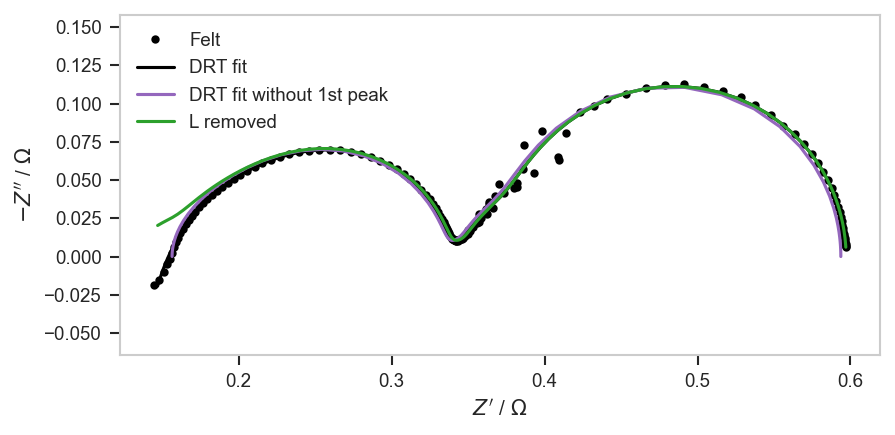

Looking for up to  6  peaks


[(np.float64(8.045805657275196e-07), np.float64(0.08756845906776176)),
 (np.float64(7.837428711354733e-06), np.float64(0.036083321073240304)),
 (np.float64(4.4788048398913816e-05), np.float64(0.12912982642423795)),
 (np.float64(0.004034362267702818), np.float64(0.005873600111265471)),
 (np.float64(0.03879094123840332), np.float64(0.061818341593418785)),
 (np.float64(0.44169697165489197), np.float64(0.8008231320555157))]

,label,peak_type,peak_number,log_tau0,height,upsilon,sigma,tau0,Z
0,peak_0,SG,0,-14.043913,0.086869,-0.063589,0.100784,7.958037e-07,0.022035
1,peak_1,SG,1,-11.716291,0.032588,-0.466749,0.855982,8.159800e-06,0.089396
2,peak_2,SG,2,-10.004806,0.109026,0.145951,0.322286,4.518224e-05,0.089994
3,peak_3,SG,3,-5.568036,0.004902,-0.096109,1.137788,3.817971e-03,0.014112
4,peak_4,SG,4,-3.234954,0.058888,0.215175,0.163512,3.936200e-02,0.025308
5,peak_5,SG,5,-0.814239,0.799097,0.066654,0.108597,4.429764e-01,0.218494


{'success': True,
 'message': 'Fit succeeded.',
 'chisqr': np.float64(0.0025125834840794272),
 'redchi': np.float64(1.73760960171468e-06),
 'nfev': 538,
 'method': 'leastsq',
 'kws sent': {'Dfun': None,
  'full_output': 1,
  'col_deriv': 0,
  'ftol': 1.5e-08,
  'xtol': 1.5e-08,
  'gtol': 0.0,
  'maxfev': 100000,
  'epsfcn': 1e-10,
  'factor': 100,
  'diag': None}}

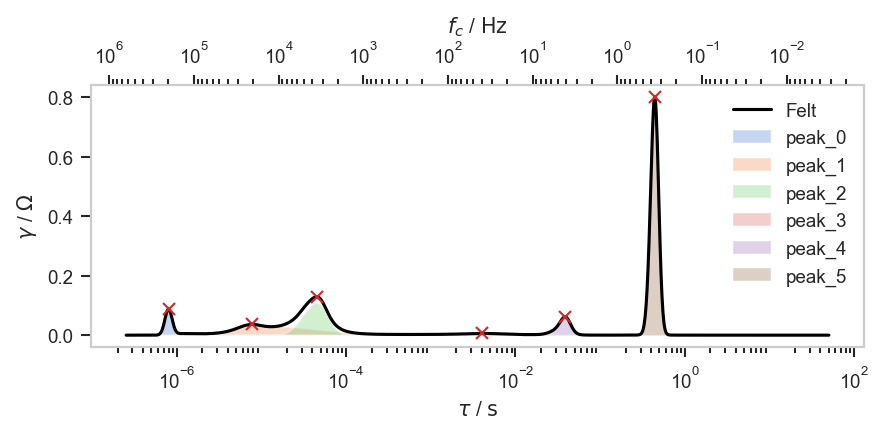

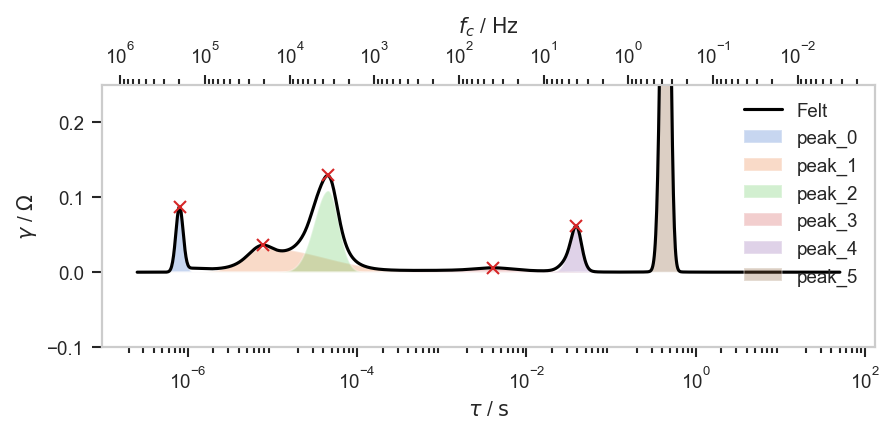

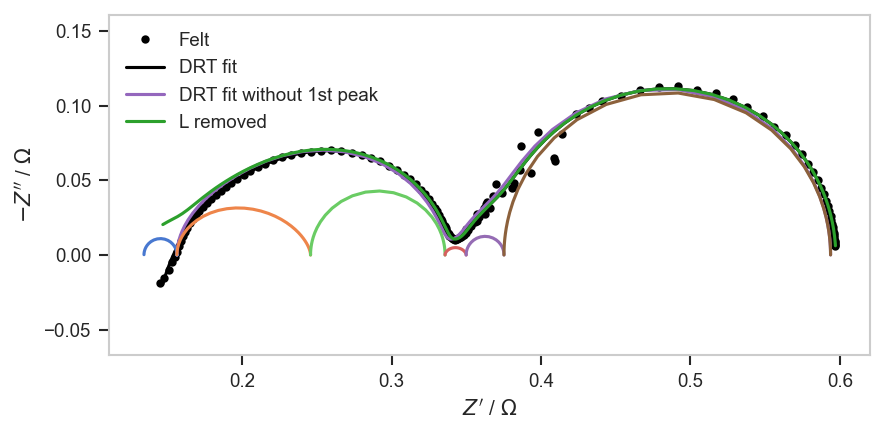

Max data Re:  0.59693724
DRT Rp: 0.4627901119300569
DRT R0: 0.13438104653357807
DRT Rp + R0: 0.597171158463635
Peak sum Z0: 0.45933889112334136
Peak sum Z0 + R0: 0.5937199376569194
Max reconstructed Z: 0.5937199276089603
Inductance L: 3.1654836308523885e-08


In [117]:
#########################
##### Data loading ######
#########################

DRTData_object = DRTData(tau = tau_pyDRTtools, gamma = gamma_pyDRTtools, label = EISData_object.label)
R = fitted_entry.R
L = fitted_entry.L

f = fitted_entry.freq
Z = fitted_entry.mu_Z_re + 1j*fitted_entry.mu_Z_im
EISData_fitted = EISData(f = f, Z = Z, label = "DRT fit")

EISData_fitted_adjust = EISData(f = f, Z = Z - 2j*f*np.pi*L, label = "L removed")

#########################
## Create Nyquist Plot ##
#########################
NyquistPlot_object = NyquistPlot(figsize=(6, 3), dpi = 150) 
for label, entry in eis_plot_dict.items():
    if entry["plot"]:
        NyquistPlot_object.add_plot(entry["data"], **entry["plot_kwargs"])
NyquistPlot_object.add_plot(EISData_fitted_adjust, linestyle = "-", color = colour_dict["green"], label = EISData_fitted_adjust.label)


NyquistPlot_object.ax.set_aspect("equal", adjustable="datalim")  # if enable, overall fig size will be strictly enforced, but x and y limits will be overwritten. So will padding of labels I think.
# # NyquistPlot_object.ax.set_aspect('equal',adjustable='box') # if enable this, fig size will get overwritten, at least in y. but can set x and y lim
# # Best way is to control size using adjustable = "datalim", and then plot invisible points to ensure points are in view if desired. Less useful for cropping.
# # NyquistPlot_object.ax.grid(True)
# NyquistPlot_object.add_major_ticks(spacing_x = 1, spacing_y = 1)
# # NyquistPlot_object.add_minor_ticks(number_x = 5, number_y = 5)
NyquistPlot_object.ax.legend()
NyquistPlot_object.fig.tight_layout() # try stop cutting off labels
display(NyquistPlot_object.fig)
# NyquistPlot_object.save("Nyquist.svg") # may need to adjust fontsize or use bbox_inches='tight' to stop cutting off labels

#########################
#### Create DRT Plot ####
#########################
DRTPlot_object = DRTPlot(figsize=(6, 3), dpi = 150)
for label, entry in drt_plot_dict.items():
    if entry["plot"]:
        DRTPlot_object.add_plot(entry["data"], **entry["plot_kwargs"])
# DRTPlot_object.add_major_ticks(spacing_y = 1)
# DRTPlot_object.add_minor_ticks(number_x = 9)
DRTPlot_object.add_fc_axis() # only use after enforcing DRTPlot_object.ax.set_xlim([0, None]) if desired
DRTPlot_object.ax.legend()
DRTPlot_object.fig.tight_layout() # try stop cutting off labels
# display(DRTPlot_object.fig)
# DRTPlot_object.save("DRT.svg") # may need to adjust fontsize or use bbox_inches='tight' to stop cutting off labels

##################
## Peak fitting ##
##################
peaks_to_fit = None
peaks_to_fit = 6
print("Looking for up to ", peaks_to_fit, " peaks")
peak_positions = find_DRT_peaks(DRTData_object = DRTData_object, num_peaks = peaks_to_fit, find_peaks_settings = dict(height=None, threshold=None, distance=None, prominence=None, width=None, wlen=None, rel_height=0.5, plateau_size=None))

# peak_positions.insert(0, (4e-6, 0.03))

display(peak_positions)

for peak_pos in peak_positions:
    DRTPlot_object.add_plot(DRTData(tau = np.array([peak_pos[0]]), gamma = np.array([peak_pos[1]])), color = colour_dict["red"], marker = "x", linestyle = "")
# display(DRTPlot_object.fig)

# # minimizer_settings = {"method": "leastsq", "fit_kws": {"ftol": 1e-8, "xtol": 1e-8, "gtol": 1e-8}}
minimizer_settings = {"method": "leastsq", "fit_kws": {}}
# peak_type = "HN"
peak_type = "SG"
skew = False
skew = True
# minimizer_settings = {"method": "least_squares", "fit_kws": {"loss": "soft_l1"}}
# minimizer_settings = {"method": "least_squares"}
# minimizer_settings = {"method": "leastsq", "fit_kws": {"ftol": 1e-10, "xtol": 1e-10, "gtol": 1e-10}}
# minimizer_settings = {"method": "powell", "fit_kws": {}} # did slightly worse than leastsq
# # minimizer_settings = {"method": "least_squares", "fit_kws": {}} # again, slightly worse
# minimizer_settings = {"method": "nelder", "fit_kws": {}} # slightly worse
# # minimizer_settings = {"method": "lbfgsb", "fit_kws": {}} # much worse with defaults
# # may also increase accuracy with more tau points
log_tau0_bound = 0.1 # about 10%, made fit much better due to easing contraint on tau0
log_tau0_bound = None
peak_fit = fit_DRT_peaks(
    DRTData_object = DRTData_object,
    peak_positions = peak_positions, # if make none, uses num_peaks to find
    num_peaks =  None, # None if using peak positions instead
    peak_type = peak_type, # select HN or SG
    skew = skew,
    log_tau0_bound = log_tau0_bound, # base e not 10
    minimizer_settings = minimizer_settings
    )

df = peak_fit.to_peaks_df()
display(df)
display(peak_fit.fit_summary)

omega = 2*np.pi*f
# Number of decades to add on each side
extra_decades = 2.0  # e.g. 1 decade below and above
# Points per decade
points_per_decade = 10
# Assume f is your original log-spaced frequency array
f_min = np.min(f)
f_max = np.max(f)
# Calculate new min and max in log10 space
log_f_min = np.log10(f_min) - extra_decades
log_f_max = np.log10(f_max) + extra_decades
# Total number of points
num_decades = log_f_max - log_f_min
num_points = int(np.ceil(num_decades * points_per_decade))
# Create expanded log-spaced frequency array
f_expanded = np.logspace(log_f_max, log_f_min, num=num_points)
omega = 2*np.pi*f_expanded

Z_tot = R

for i, peak in enumerate(peak_fit):
    # DRTPlot_object.add_plot(DRTData(tau = DRTData_object.tau, gamma = peak.get_gamma(tau=DRTData_object.tau), label = peak.label))
    DRTPlot_object.ax.fill_between(DRTData_object.tau, peak_fit.get_gamma(tau=DRTData_object.tau, peak_indices = [i]), 0, where=(peak_fit.get_gamma(tau=DRTData_object.tau) >= 0), alpha=0.3, label = df[df['peak_number']==i]['label'].values[0])
    if peak_type == "HN":
        peak_row = df[df['peak_number']==i]
        alpha = peak_row['alpha'].values[0]
        beta = peak_row['beta'].values[0]
        tau0 = peak_row['tau0'].values[0]
        Z0 = peak_row['Z0'].values[0]
        Z_peak = Z_tot + HN_Z(omega, Z0, tau0, alpha, beta)
    elif peak_type == "SG":
        # def gamma_func(tau):
        #     return peak.get_gamma(tau)
        #Z_peak = Z_tot + Z_from_DRT(f_expanded, gamma = gamma_func)
        Z_peak = Z_tot + Z_from_DRT(f_expanded, gamma = peak.get_gamma)
    Z_peak_re = np.real(Z_peak)
    Z_peak_im = np.imag(Z_peak)
    Z_tot = Z_peak_re[-1] # update total
    # not using EISData objects as frequency loses meaning
    NyquistPlot_object.ax.plot(Z_peak_re, -Z_peak_im)

DRTPlot_object.ax.legend()
#DRTPlot_object.ax.set_ylim(-0.1, 0.5)
display(DRTPlot_object.fig)
DRTPlot_object.ax.set_ylim(-0.1, 0.25)
display(DRTPlot_object.fig)

display(NyquistPlot_object.fig)

print("Max data Re: ", np.max(EISData_object.Z_re))
print("DRT Rp:", DRTData_object.get_pol_resistance())
print("DRT R0:", R)
print("DRT Rp + R0:", DRTData_object.get_pol_resistance() + R)
print("Peak sum Z0:", df['Z'].sum())
print("Peak sum Z0 + R0:", df['Z'].sum() + R)
print("Max reconstructed Z:", np.max(Z_peak_re))
print("Inductance L:", L)




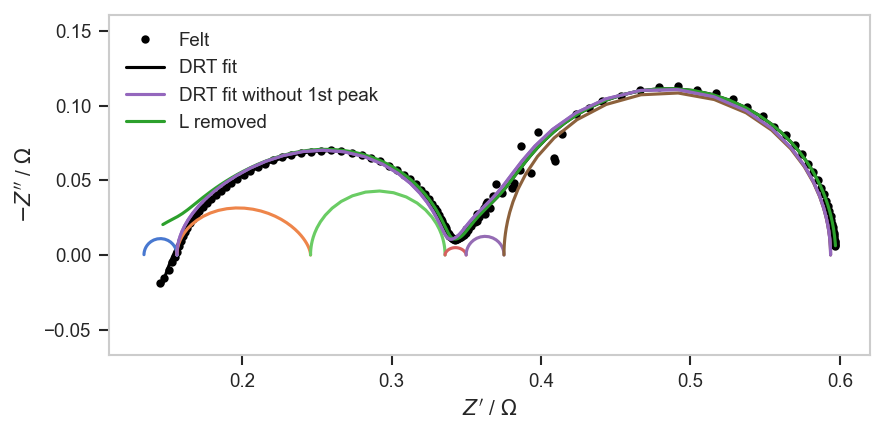

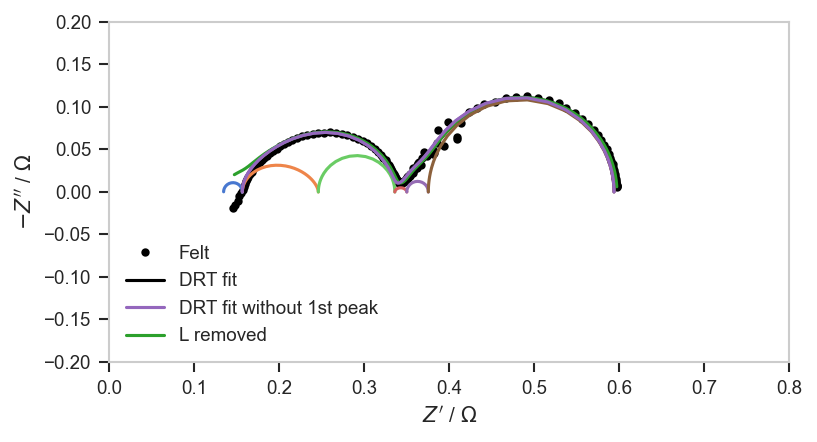

In [118]:
def gamma_func(tau):
    peak_indices = list(range(len(peak_fit.peaks)))  # e.g. [0, 1, 2, 3]
    selected_indices = peak_indices[1:]    # [1, 2, 3]
    gamma_func = peak_fit.get_gamma(tau = tau, peak_indices = selected_indices)
    return gamma_func
Z_adjust = Z_from_DRT(f_expanded, gamma = gamma_func, R0 = R + df[df['peak_number']==0]['Z'].values[0] , L0 = 0)
EISData_fitted_adjust_peaks = EISData(f = f_expanded, Z = Z_adjust, label = "DRT fit without 1st peak")
eis_plot_dict[EISData_fitted_adjust_peaks.label] = {
        "data": EISData_fitted_adjust_peaks,
        "plot_kwargs": {"color": colour_dict["purple"], "linestyle": "-", "marker": "", "label": EISData_fitted_adjust_peaks.label},
        "plot": True
    }   
NyquistPlot_object.add_plot(EISData_fitted_adjust_peaks, linestyle = "-", color = colour_dict["purple"], label = EISData_fitted_adjust_peaks.label)
display(NyquistPlot_object.fig)

NyquistPlot_object.ax.set_aspect('equal',adjustable='box')
NyquistPlot_object.ax.set_ylim(-0.2, 0.2)
NyquistPlot_object.ax.set_xlim(0, 0.8)
display(NyquistPlot_object.fig)


In [ ]:
[1,2,3,4][1:]

[2, 3, 4]